Part 1:

Import Libraries
We start by importing the standard libraries for data handling and visualization.

In [ ]:
import tarfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Set visualization style
sns.set(style="whitegrid")

Part 2:

Import Machine Learning Tools

We import the specific Scikit-Learn tools needed for Feature Engineering and Modeling.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Part 3:

MOUNT DRIVE


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Part 4:

Load Data

Reads the CSV files for Genes (data.csv) and Diagnoses (labels.csv).

In [ ]:
print("Loading CSV files...")
df_data = pd.read_csv('/content/drive/MyDrive/data.csv', index_col=0)
df_labels = pd.read_csv('/content/drive/MyDrive/labels.csv', index_col=0)
print("Files Loaded.")

Loading CSV files...
Files Loaded.


Part 5:

Align Data

Merges the two files to ensure Sample ID alignment.

In [ ]:
# Merge to ensure alignment
full_set = df_data.merge(df_labels, left_index=True, right_index=True)

# Separate Features (X) and Target (y)
X = full_set.iloc[:, :-1]
y = full_set.iloc[:, -1]
print("Alignment Complete.")

Alignment Complete.


Part 6:
Encode Labels

Converts text labels (e.g., 'BRCA') into numbers (e.g., 0).

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes encoded: {le.classes_}")

Classes encoded: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']


Part 7:

Check Data Shape

Verifies the number of patients and genes.

In [ ]:
print(f"Total Samples: {X.shape[0]}")
print(f"Total Genes (Features): {X.shape[1]}")

Total Samples: 801
Total Genes (Features): 20531


Part 8:
Train-Test Split (Prevent Leakage)

Splits data 80/20 before processing to prevent data leakage.

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Training Data Shape: {X_train_raw.shape}")
print(f"Test Data Shape: {X_test_raw.shape}")

Training Data Shape: (640, 20531)
Test Data Shape: (161, 20531)


Part 9:
Define Noise Filter

Prepares to remove genes with 0 variance (constant values).

In [ ]:
var_filter = VarianceThreshold(threshold=0.0)

Part 10:
Apply Noise Filter

Removes constant genes from Train and Test sets.

In [ ]:
X_train_filtered = var_filter.fit_transform(X_train_raw)
X_test_filtered = var_filter.transform(X_test_raw)
print(f"Genes Remaining: {X_train_filtered.shape[1]}")

Genes Remaining: 20254


Part 11:

Biomarker Discovery

Text: Finds the top 20 genes using the Chi-Squared statistical test.

In [ ]:
selector = SelectKBest(score_func=chi2, k=20)
selector.fit(X_train_filtered, y_train)
print("Biomarker selection fitted.")

Biomarker selection fitted.


Part 12:
List Biomarkers

Prints the names of the top 20 biomarkers found.

In [ ]:
mask_var = var_filter.get_support()
selected_indices = selector.get_support(indices=True)
gene_names = X.columns[mask_var]
top_genes = gene_names[selected_indices]
print("Top 20 Biomarkers:", list(top_genes))

Top 20 Biomarkers: ['gene_219', 'gene_220', 'gene_450', 'gene_3439', 'gene_5829', 'gene_9175', 'gene_9176', 'gene_11903', 'gene_12069', 'gene_12995', 'gene_13976', 'gene_15591', 'gene_15895', 'gene_15896', 'gene_15898', 'gene_15899', 'gene_16132', 'gene_16169', 'gene_18135', 'gene_19153']


Part 13:
Scaling (Standardization)

Scales data to Mean=0, Variance=1 (Required for SVM/PCA).

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_filtered)
print("Data Scaled.")

Data Scaled.


Part 14:
PCA (Dimensionality Reduction)

Compresses genes into Principal Components (95% variance retained).

In [ ]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"PCA Components: {X_train_pca.shape[1]}")

PCA Components: 434


Part 15:

t-SNE Visualization Setup

Runs t-SNE on the PCA data to visualize clusters.

In [ ]:
print("Running t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_train_tsne = tsne.fit_transform(X_train_pca)
print("t-SNE Complete.")

Running t-SNE (this may take a moment)...
t-SNE Complete.


Part 16:

Visualize Clusters

Plots PCA (Linear) vs t-SNE (Non-Linear) projections.

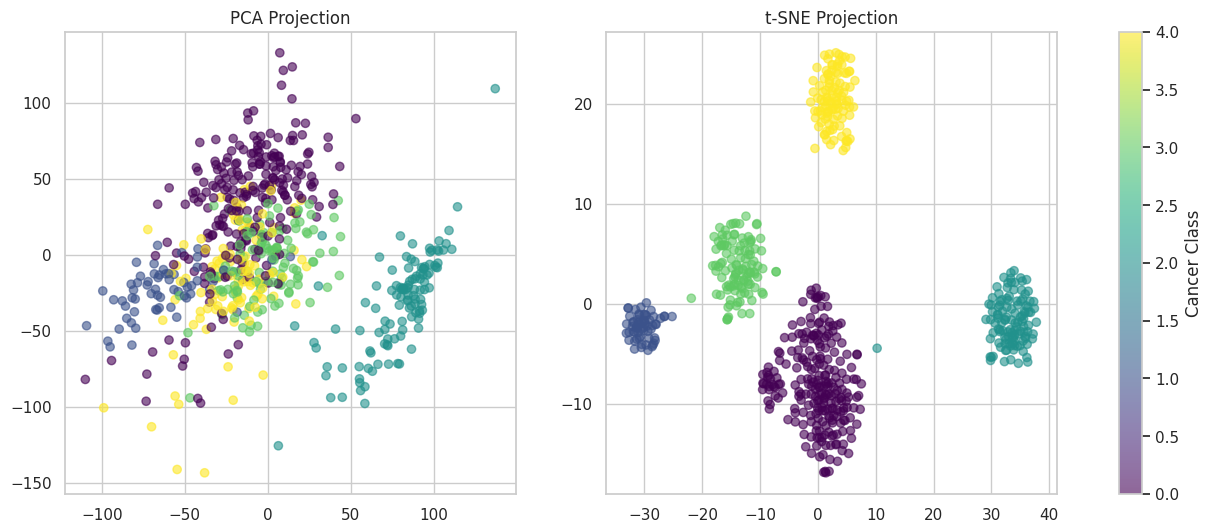

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot PCA
scatter1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.6)
axes[0].set_title('PCA Projection')

# Plot t-SNE
scatter2 = axes[1].scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap='viridis', alpha=0.6)
axes[1].set_title('t-SNE Projection')

plt.colorbar(scatter2, ax=axes, label='Cancer Class')
plt.show()

Part 17:

MASTER EVALUATION FUNCTION

This function handles all "checking". It plots the Confusion Matrix and prints the Full Report for any model you send it.

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    # 1. Predict
    y_pred = model.predict(X_test)

    # 2. Calculate Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"--- {model_name} EVALUATION ---")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # 3. Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()
    return acc

Part 18:

Train & Check k-NN

Trains k-NN and checks accuracy + confusion matrix.

--- k-NN EVALUATION ---
Accuracy: 0.9752

Classification Report:
              precision    recall  f1-score   support

        BRCA       0.97      0.98      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      0.97      0.98        30
        LUAD       1.00      0.93      0.96        28
        PRAD       0.93      1.00      0.96        27

    accuracy                           0.98       161
   macro avg       0.98      0.98      0.98       161
weighted avg       0.98      0.98      0.98       161



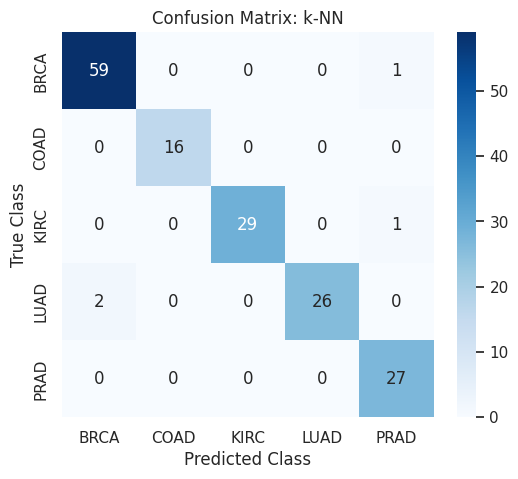

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)  # <--- TRAINING HAPPENS HERE
acc_knn = evaluate_model(knn, X_test_pca, y_test, "k-NN")

Part 19:
Train & Check SVM

Trains SVM and checks accuracy + confusion matrix.

--- SVM EVALUATION ---
Accuracy: 0.9938

Classification Report:
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



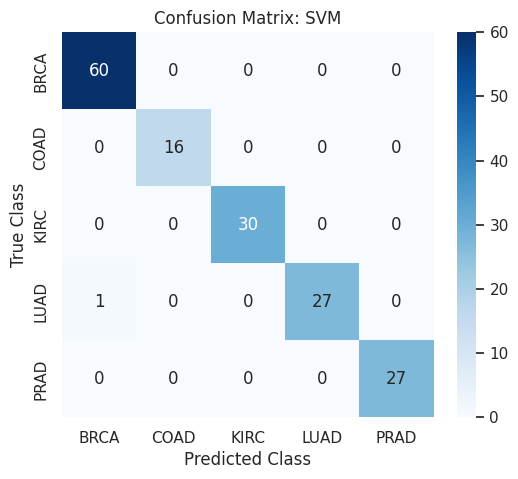

In [ ]:
svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train_pca, y_train)  # <--- TRAINING HAPPENS HERE
acc_svm = evaluate_model(svm, X_test_pca, y_test, "SVM")

Part 20:

Train & Check Random Forest

Trains Random Forest and checks accuracy + confusion matrix.

--- Random Forest EVALUATION ---
Accuracy: 0.8944

Classification Report:
              precision    recall  f1-score   support

        BRCA       0.82      1.00      0.90        60
        COAD       1.00      0.75      0.86        16
        KIRC       1.00      0.97      0.98        30
        LUAD       0.95      0.64      0.77        28
        PRAD       0.89      0.93      0.91        27

    accuracy                           0.89       161
   macro avg       0.93      0.86      0.88       161
weighted avg       0.91      0.89      0.89       161



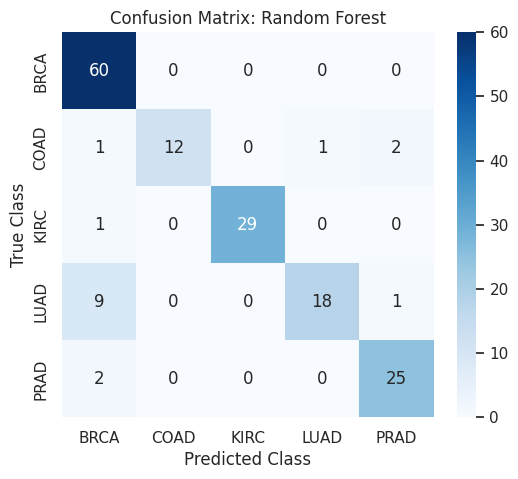

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_pca, y_train)   # <--- TRAINING HAPPENS HERE
acc_rf = evaluate_model(rf, X_test_pca, y_test, "Random Forest")

Part 21:

Train & Check LDA

Trains LDA and checks accuracy + confusion matrix.

--- LDA EVALUATION ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



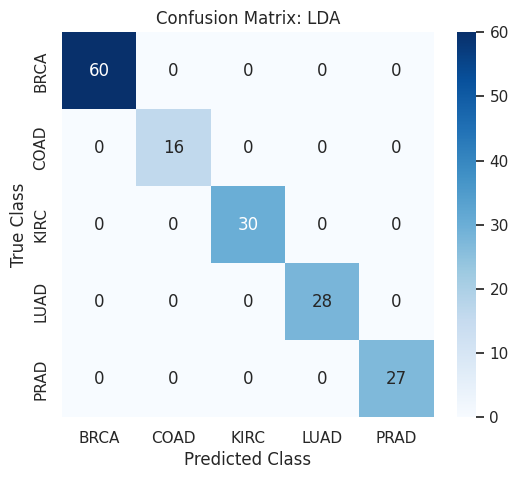

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_pca, y_train)  # <--- TRAINING HAPPENS HERE
acc_lda = evaluate_model(lda, X_test_pca, y_test, "LDA")

Part 22:

Final Accuracy Comparison

A final bar chart to compare who won.

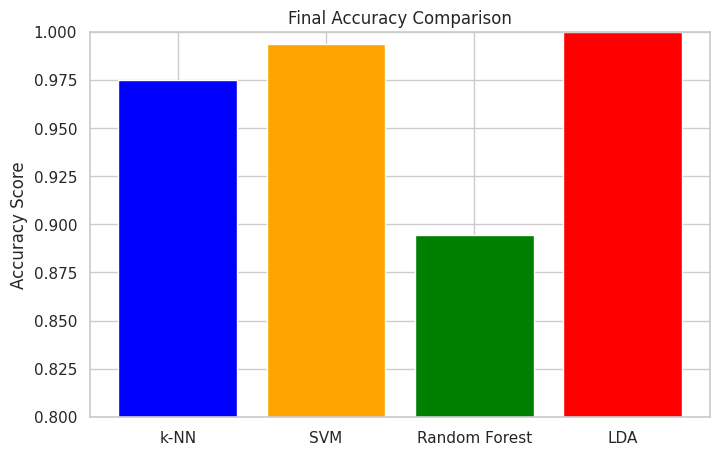

Best Model: LDA


In [ ]:
model_scores = {'k-NN': acc_knn, 'SVM': acc_svm, 'Random Forest': acc_rf, 'LDA': acc_lda}

plt.figure(figsize=(8, 5))
plt.bar(model_scores.keys(), model_scores.values(), color=['blue', 'orange', 'green', 'red'])
plt.ylim(0.8, 1.0)  # Zoom in to see differences
plt.title('Final Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.show()

print(f"Best Model: {max(model_scores, key=model_scores.get)}")

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# 1. LOAD TRAINING DATA (GLOBAL)
# ==========================================
print("⏳ Loading Global Training Data...")

# Set correct paths to Google Drive
data_path = '/content/drive/MyDrive/data.csv'
labels_path = '/content/drive/MyDrive/labels.csv'

if not os.path.exists(data_path) or not os.path.exists(labels_path):
    raise FileNotFoundError(f"❌ Error: '{os.path.basename(data_path)}' or '{os.path.basename(labels_path)}' not found in Google Drive. Make sure they are there.")

# Load full dataset once into memory
df_data = pd.read_csv(data_path, index_col=0)
df_labels = pd.read_csv(labels_path, index_col=0)

# Global variables
X_full = df_data.merge(df_labels, left_index=True, right_index=True).iloc[:, :-1]
y_full = df_labels.iloc[:, 0]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_full)

print(f"✅ Data Loaded. Ready for user input.")

# ==========================================
# 2. DYNAMIC PROCESSING FUNCTION
# ==========================================
def run_custom_analysis(file_obj, gene_string):
    """
    1. Reads user's gene list.
    2. Retrains model ON THE FLY using only those genes.
    3. Predicts on the uploaded file.
    """
    if file_obj is None:
        return "⚠️ Please upload a CSV file first."

    if not gene_string or gene_string.strip() == "":
        return "⚠️ Please specify at least one gene."

    # 1. Parse User's Gene List
    # Split by comma, strip spaces
    selected_genes = [g.strip() for g in gene_string.split(',') if g.strip()]

    # 2. Validate Genes
    # Check if these genes exist in our training data
    missing_genes = [g for g in selected_genes if g not in X_full.columns]
    if missing_genes:
        return f"❌ Error: The following genes were not found in the database: {', '.join(missing_genes)}"

    if len(selected_genes) == 0:
        return "⚠️ No valid genes selected."

    try:
        # 3. Retrain Model (Specific to these genes)
        print(f"⚙️ Retraining model on {len(selected_genes)} specific genes...")

        # Slice the global training data
        X_train_subset = X_full[selected_genes]

        # Scale
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_subset)

        # Train (Balanced for Bias Correction)
        clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
        clf.fit(X_train_scaled, y_encoded)

        # 4. Process Uploaded Patient File
        input_df = pd.read_csv(file_obj.name, index_col=0)

        # Transpose if necessary (if genes are rows)
        if input_df.shape[0] > 1000 and input_df.shape[1] < 1000:
            input_df = input_df.T

        # Check if uploaded file has the selected genes
        missing_in_upload = [g for g in selected_genes if g not in input_df.columns]
        if missing_in_upload:
            return f"❌ Error: Your uploaded file is missing these columns: {', '.join(missing_in_upload)}"

        # Select and Scale Patient Data
        X_patient = input_df[selected_genes]
        X_patient_scaled = scaler.transform(X_patient)

        # 5. Predict
        probs = clf.predict_proba(X_patient_scaled)[0]

        # Return Result
        return {le.classes_[i]: float(probs[i]) for i in range(len(le.classes_))}

    except Exception as e:
        return f"❌ System Error: {str(e)}"

# ==========================================
# 3. GRADIO INTERFACE
# ==========================================
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🧬 Custom Gene Targeter")
    gr.Markdown("Upload a patient file, then specify exactly which genes to analyze. The model will **retrain instantly** to focus only on your selection.")

    with gr.Row():
        with gr.Column():
            # Input 1: File
            file_input = gr.File(label="Step 1: Upload Patient CSV")

            # Input 2: Text Box
            gene_input = gr.Textbox(
                label="Step 2: Enter Genes (comma separated)",
                placeholder="e.g. gene_1234, gene_567, gene_890",
                lines=2
            )

            # Button
            btn = gr.Button("🚀 Train & Diagnose", variant="primary")

        with gr.Column():
            # Output
            output_label = gr.Label(num_top_classes=5, label="Diagnosis Result")

    # Click Event
    btn.click(fn=run_custom_analysis, inputs=[file_input, gene_input], outputs=output_label)

if __name__ == "__main__":
    demo.launch()

⏳ Loading Global Training Data...
✅ Data Loaded. Ready for user input.


/tmp/ipython-input-3951104353.py:106: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5b9025d6f1cb7ef1c4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
